In [16]:
#Cell 1 : Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import warnings
warnings.filterwarnings('ignore')

In [17]:
#Cell 2 : Load Dataset
df = pd.read_csv(r"C:\Users\SURANJANA MAJUMDAR\Desktop\Insurance Claim Amount Prediction\archive.zip")
df.head()

,policy_id,customer_name,gender,age,marital_status,state,city,pincode,aadhaar_masked,occupation_type,...,length_of_stay,cashless_claim,agent_channel,hospital_bill_amount,pre_hospitalization_expense,post_hospitalization_expense,non_payable_items,deductible_amount,co_pay_amount,total_claim_amount
0,IND103304,Alka Mukhopadhyay,F,36,Divorced,Tamil Nadu,Chennai,847016,XXXX-XXXX-6575,Business,...,6,yes,online,160039.77,15092.716958,14816.007640,5229.900734,6634.961901,26405.574579,"₹151,678"
1,IND101987,Gautami Chanda,F,39,married,Karnataka,Bengaluru,432335,XXXX-XXXX-2872,Retired,...,6,no,bancassurance,173704.83,14920.655851,10384.480861,12756.023431,6987.996116,16771.482336,162494.46
2,IND104725,Ridhi Wable,Male,48,married,Karnataka,Bengaluru,807064,XXXX-XXXX-9125,Self-employed,...,5,yes,agent,220261.47,16202.882187,19974.634737,9624.570612,10524.495687,31255.241298,205034.68
3,IND105031,Ethan Shankar,M,46,Widowed,Tamil Nadu,Coimbatore,900329,XXXX-XXXX-1493,Self-employed,...,5,no,aggregator,128736.67,9340.872259,6760.021670,2622.298761,6400.820348,21994.193710,512986.56
4,IND107599,Logan Chaudhry,F,18,Married,Tamil Nadu,Chennai,466064,286274455107,Unemployed,...,5,yes,aggregator,148014.44,16595.311362,17123.418402,11346.864183,1550.856123,21866.765755,"₹146,969"


In [18]:
#Cell 3 : Dataset Overview
print("Shape of Dataset:", df.shape)
df.info()
df.describe()

Shape of Dataset: (8000, 38)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   policy_id                     8000 non-null   object 
 1   customer_name                 8000 non-null   object 
 2   gender                        8000 non-null   object 
 3   age                           8000 non-null   int64  
 4   marital_status                8000 non-null   object 
 5   state                         8000 non-null   object 
 6   city                          8000 non-null   object 
 7   pincode                       8000 non-null   int64  
 8   aadhaar_masked                8000 non-null   object 
 9   occupation_type               8000 non-null   object 
 10  annual_income_inr             7440 non-null   object 
 11  bmi                           7440 non-null   float64
 12  tobacco_usage                 800

,age,pincode,bmi,alcohol_units_per_week,has_diabetes,has_hypertension,family_history_cardiac,stress_level_score,sum_insured,icu_days,length_of_stay,pre_hospitalization_expense,post_hospitalization_expense,non_payable_items,deductible_amount,co_pay_amount
count,8000.000000,8000.000000,7440.000000,8000.000000,7617.000000,7609.000000,8000.000000,7440.000000,8.000000e+03,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,41.765750,541655.027125,25.989768,3.002750,0.216752,0.266132,0.340750,5.034356,1.746775e+06,0.997625,3.988250,12068.054936,10318.104601,6109.982575,3642.514291,15362.882500
std,15.099748,264560.690471,4.905202,1.732301,0.412059,0.441963,0.473991,1.939953,1.715205e+06,0.996365,2.002464,6647.854481,5482.729520,3628.137717,2263.262191,9165.052303
min,18.000000,13587.000000,15.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000e+05,0.000000,0.000000,-1842.506228,-1669.771508,-1260.602175,-499.309969,-2253.341868
25%,30.000000,309657.500000,22.539459,2.000000,0.000000,0.000000,0.000000,3.685944,5.000000e+05,0.000000,3.000000,7236.080973,6371.690716,3422.566220,1934.620934,8641.197227
50%,41.000000,538704.500000,25.996548,3.000000,0.000000,0.000000,0.000000,5.030104,1.000000e+06,1.000000,4.000000,10856.898848,9331.231864,5371.192401,3152.132876,13455.742946
75%,52.000000,773501.000000,29.330098,4.000000,0.000000,1.000000,1.000000,6.383080,2.000000e+06,2.000000,5.000000,15567.766654,13188.208812,8012.995460,4839.563036,20200.219709
max,85.000000,999797.000000,43.682658,11.000000,1.000000,1.000000,1.000000,10.000000,5.000000e+06,6.000000,13.000000,55993.747135,43600.021952,27252.866177,18921.640284,73377.223456


In [19]:
#Cell 4 : Data Cleaning
currency_cols = ['annual_income_inr','hospital_bill_amount','total_claim_amount']
for col in currency_cols:
    df[col] = (df[col].astype(str).str.replace('₹', '', regex=False).str.replace(',', '', regex=False))
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [20]:
#Cell 5 : Missing Value Treatment
print(df.isnull().sum())
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
# Categorical columns
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

policy_id                          0
customer_name                      0
gender                             0
age                                0
marital_status                     0
state                              0
city                               0
pincode                            0
aadhaar_masked                     0
occupation_type                    0
annual_income_inr               1194
bmi                              560
tobacco_usage                      0
alcohol_units_per_week             0
physical_activity_level            0
diet_type                          0
has_diabetes                     383
has_hypertension                 391
family_history_cardiac             0
stress_level_score               560
policy_type                        0
sum_insured                        0
policy_start_date                  0
claim_date                         0
hospital_name                      0
hospital_tier                      0
room_category                      0
i

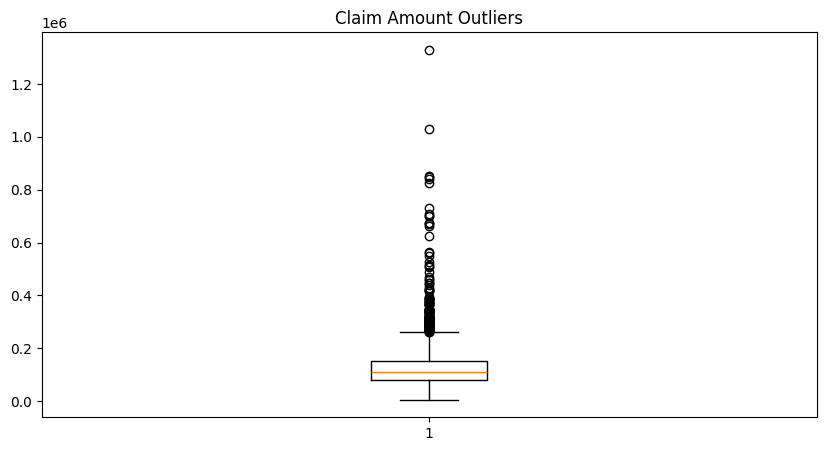

In [21]:
#Cell 6 : Outlier Detection
plt.figure(figsize=(10,5))
plt.boxplot(df['total_claim_amount'])
plt.title("Claim Amount Outliers")
plt.show()

In [22]:
#Cell 7 : Outlier Handling
Q1 = df['total_claim_amount'].quantile(0.25)
Q3 = df['total_claim_amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['total_claim_amount'] >= lower) &(df['total_claim_amount'] <= upper)]

In [23]:
#Cell 8 : Drop Unnecessary Columns
drop_cols = ['policy_id','customer_name','aadhaar_masked','policy_start_date','claim_date']
df.drop(columns=drop_cols, inplace=True)

In [24]:
#Cell 9 : Encode Categorical Features
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [25]:
#Cell 10 : Feature and Target Separation
X = df.drop('total_claim_amount', axis=1)
y = df['total_claim_amount']
print(X.shape)
print(y.shape)

(7826, 32)
(7826,)


In [26]:
#Cell 11 : Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print(X_train.shape)
print(X_test.shape)

(6260, 32)
(1566, 32)


In [27]:
#Cell 12 : Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [28]:
#Cell 13 : Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [29]:
#Cell 14 : Model Evaluation
models = {"Linear Regression": lr_pred,"Random Forest": rf_pred}
for name, pred in models.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print("\n", name)
    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("R2  :", round(r2,4))


 Linear Regression
MAE : 1031.27
RMSE: 7931.57
R2  : 0.9757

 Random Forest
MAE : 3205.24
RMSE: 8873.93
R2  : 0.9696


                         Feature  Importance
26          hospital_bill_amount    0.963643
31                 co_pay_amount    0.012017
27   pre_hospitalization_expense    0.005818
28  post_hospitalization_expense    0.003244
29             non_payable_items    0.003050
1                            age    0.001773
16            stress_level_score    0.001239
30             deductible_amount    0.001153
5                        pincode    0.000972
19                 hospital_name    0.000692


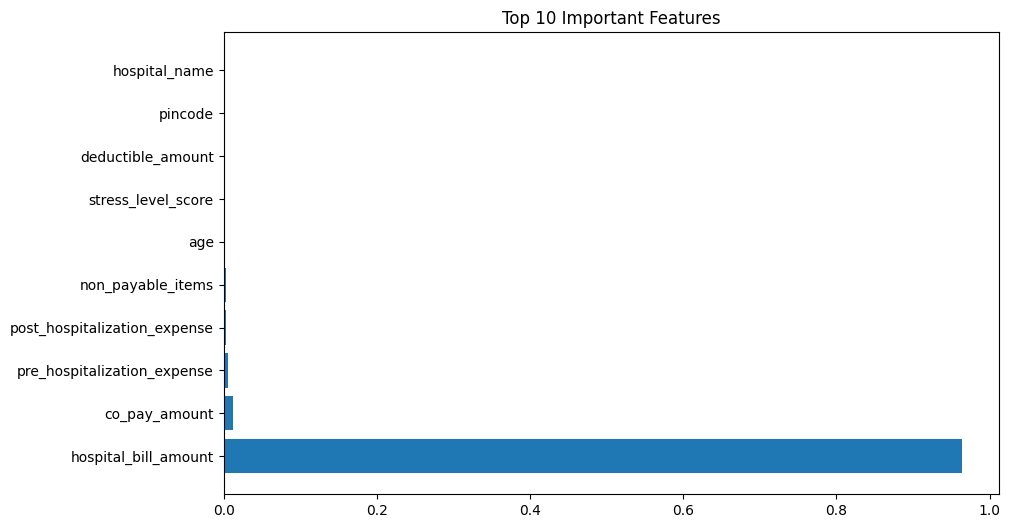

In [30]:
#Cell 15 : Feature Importance
importance = pd.DataFrame({'Feature': X.columns,'Importance': rf.feature_importances_})
importance = importance.sort_values(by='Importance',ascending=False)
print(importance.head(10))
top10 = importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.title("Top 10 Important Features")
plt.show()